# Simple Credit Analysis

Este notebook usa dados públicos do LendingClub para prever se um mutuário não pagará integralmente o empréstimo (`not.fully.paid`). O fluxo cobre exploração dos dados, preparação das variáveis, treinamento de modelos de árvore e avaliação com foco na classe minoritária.

## Resumo

- **Dataset**: empréstimos de 2007 a 2010 do LendingClub, com 9.578 registros.
- **Objetivo**: classificar `not.fully.paid`, em que 1 indica empréstimo não pago integralmente.
- **Abordagem**: análise exploratória, codificação de variável categórica, Decision Tree e Random Forest.
- **Ponto crítico**: a base é desbalanceada, com cerca de 84% de pagadores e 16% de não pagadores.

## Resultados de referência

| Modelo | Acurácia | Precision classe 1 | Recall classe 1 | F1-score classe 1 |
| --- | ---: | ---: | ---: | ---: |
| Decision Tree | 72% | 19% | 24% | 21% |
| Random Forest | 85% | 52% | 3% | 5% |

A acurácia do Random Forest deve ser interpretada com cautela, pois o recall da classe 1 é baixo. Para risco de crédito, deixar de identificar possíveis inadimplentes tende a ser mais custoso do que rejeitar bons pagadores.


## 1. Contexto

O LendingClub conectava mutuários e investidores. Neste projeto, o interesse é estimar se um empréstimo será pago integralmente, ajudando a comparar perfis de risco. Os dados analisados cobrem empréstimos de 2007 a 2010.

A variável alvo é `not.fully.paid`: valor 0 para empréstimos pagos integralmente e valor 1 para empréstimos não pagos integralmente.


## 2. Dataset

| Variável | Descrição | Tipo |
| --- | --- | --- |
| `credit.policy` | Indica se o cliente atende à política de crédito do LendingClub | Inteiro |
| `purpose` | Finalidade do empréstimo | Categórica |
| `int.rate` | Taxa de juros | Numérica |
| `installment` | Parcela mensal | Numérica |
| `log.annual.inc` | Logaritmo da renda anual | Numérica |
| `dti` | Razão dívida/renda | Numérica |
| `fico` | Score FICO | Inteiro |
| `days.with.cr.line` | Dias com linha de crédito | Numérica |
| `revol.bal` | Saldo rotativo | Inteiro |
| `revol.util` | Utilização do crédito rotativo | Numérica |
| `inq.last.6mths` | Consultas de crédito nos últimos 6 meses | Inteiro |
| `delinq.2yrs` | Inadimplências nos últimos 2 anos | Inteiro |
| `pub.rec` | Registros públicos depreciativos | Inteiro |
| `not.fully.paid` | Alvo: 1 para não pago integralmente, 0 para pago | Inteiro |


## 3. Carregamento e exploração inicial


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")


In [29]:
df = pd.read_csv("loan_data.csv")
df.head()


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [30]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB


In [31]:
df.describe().round(2)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.0,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00
mean,0.8,0.12,319.09,10.93,12.61,710.85,4560.77,16913.96,46.80,1.58,0.16,0.06,0.16
std,0.4,0.03,207.07,0.61,6.88,37.97,2496.93,33756.19,29.01,2.20,0.55,0.26,0.37
min,0.0,0.06,15.67,7.55,0.00,612.00,178.96,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.0,0.10,163.77,10.56,7.21,682.00,2820.00,3187.00,22.60,0.00,0.00,0.00,0.00
50%,1.0,0.12,268.95,10.93,12.66,707.00,4139.96,8596.00,46.30,1.00,0.00,0.00,0.00
75%,1.0,0.14,432.76,11.29,17.95,737.00,5730.00,18249.50,70.90,2.00,0.00,0.00,0.00
max,1.0,0.22,940.14,14.53,29.96,827.00,17639.96,1207359.00,119.00,33.00,13.00,5.00,1.00


In [32]:
df["not.fully.paid"].value_counts(normalize=True).rename("proportion").to_frame().round(3)


,proportion
not.fully.paid,
0,0.84
1,0.16


## 4. Análise exploratória

A análise visual compara score FICO, política de crédito, status de pagamento, finalidade do empréstimo e taxa de juros.


In [33]:
def plot_histogram_with_means(data, feature, group_col, figsize=(10, 6), bins=20):
    plt.figure(figsize=figsize)

    for group_value in sorted(data[group_col].unique()):
        group_data = data.loc[data[group_col] == group_value, feature]
        group_data.hist(alpha=0.5, bins=bins, label=f"{group_col} = {group_value}")

    plt.axvline(
        x=data[feature].mean(),
        color="black",
        linestyle="dashed",
        linewidth=2,
        label=f"Média geral de {feature}",
    )

    for group_value in sorted(data[group_col].unique()):
        group_mean = data.loc[data[group_col] == group_value, feature].mean()
        plt.axvline(
            x=group_mean,
            linestyle="dashed",
            linewidth=1.5,
            label=f"Média {group_col} = {group_value}",
        )

    plt.xlabel(feature)
    plt.ylabel("Frequência")
    plt.title(f"Distribuição de {feature} por {group_col}")
    plt.legend()
    plt.grid(alpha=0.3)


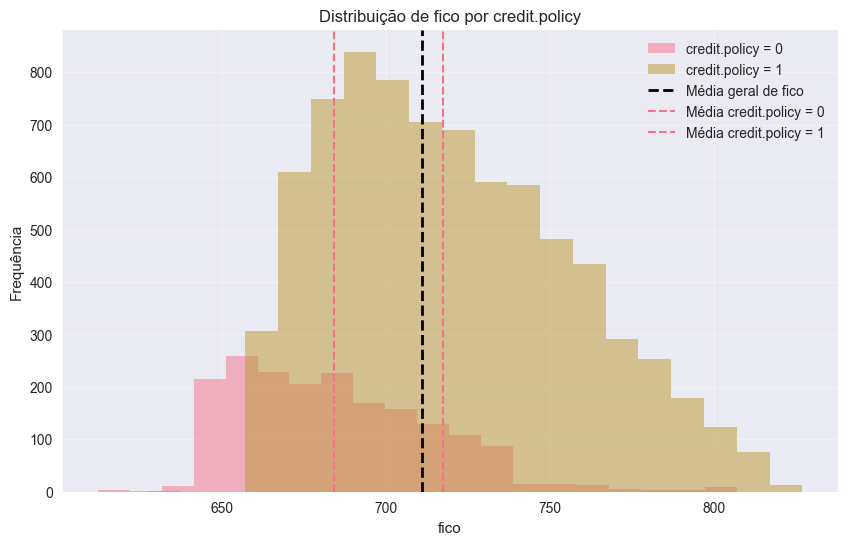

In [34]:
plot_histogram_with_means(df, "fico", "credit.policy")


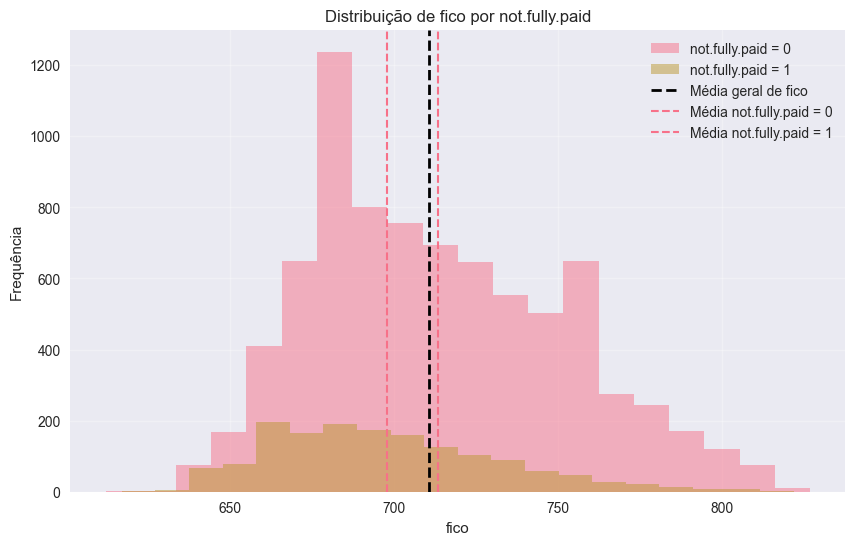

In [35]:
plot_histogram_with_means(df, "fico", "not.fully.paid")


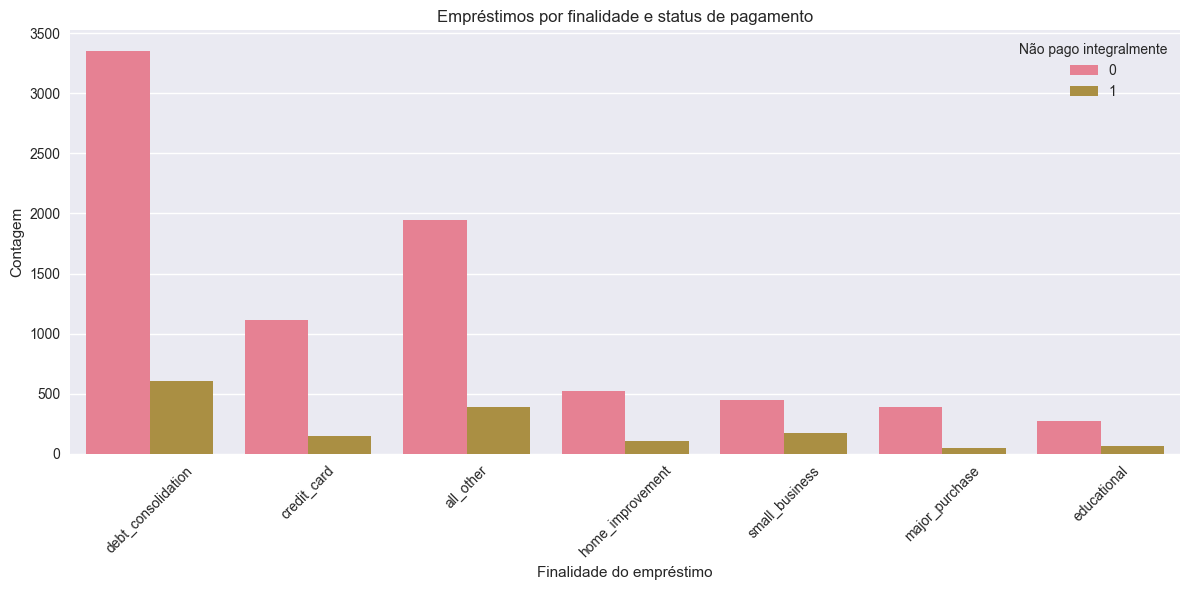

In [36]:
plt.figure(figsize=(12, 6))
sns.countplot(x="purpose", hue="not.fully.paid", data=df)
plt.title("Empréstimos por finalidade e status de pagamento")
plt.xlabel("Finalidade do empréstimo")
plt.ylabel("Contagem")
plt.xticks(rotation=45)
plt.legend(title="Não pago integralmente")
plt.tight_layout()


Text(0.5, 1.02, 'Relação entre FICO e taxa de juros')

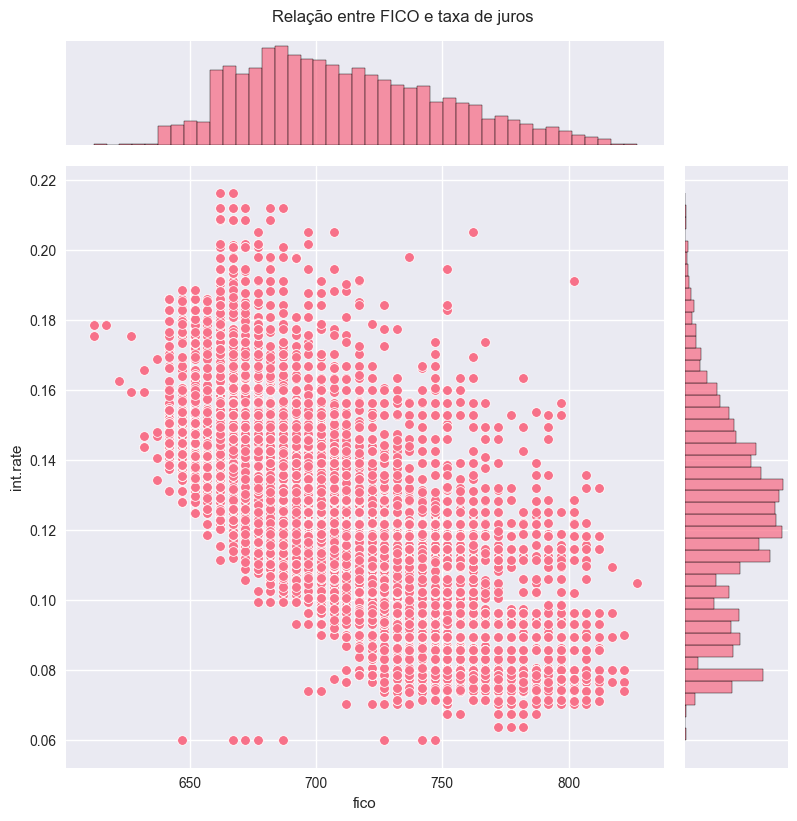

In [37]:
sns.jointplot(x="fico", y="int.rate", data=df, height=8)
plt.suptitle("Relação entre FICO e taxa de juros", y=1.02)


Text(0.5, 1.02, 'FICO e taxa de juros por política de crédito e pagamento')

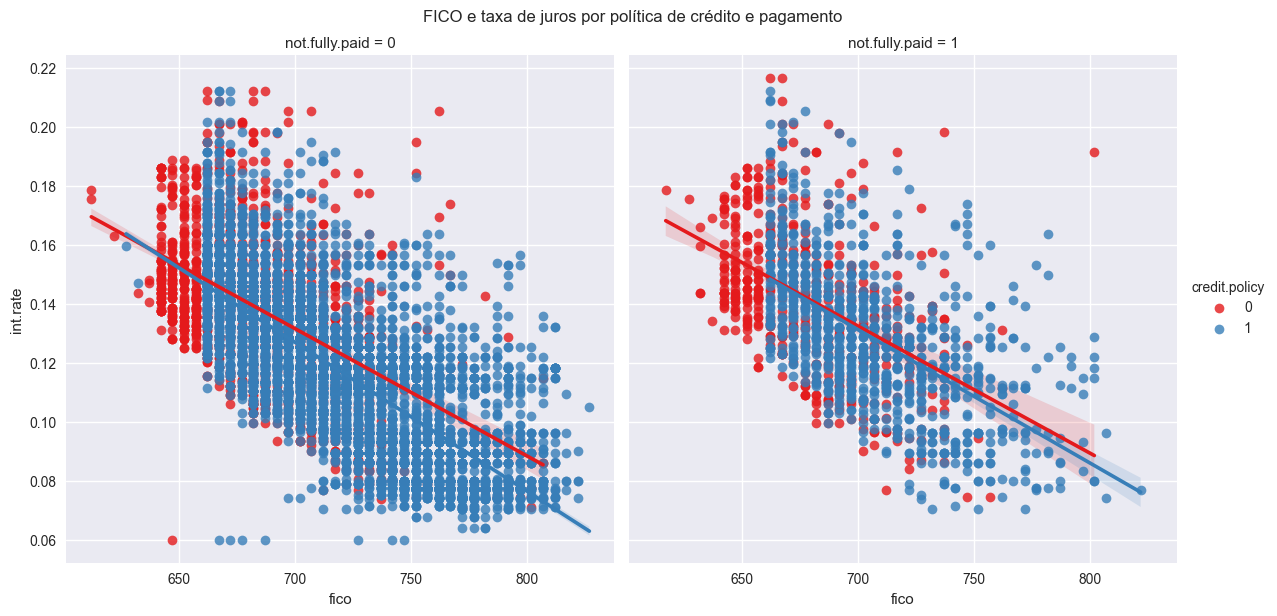

In [38]:
sns.lmplot(
    x="fico",
    y="int.rate",
    data=df,
    hue="credit.policy",
    col="not.fully.paid",
    palette="Set1",
    height=6,
)
plt.suptitle("FICO e taxa de juros por política de crédito e pagamento", y=1.02)


## 5. Preparação dos dados

A variável `purpose` é codificada com one-hot encoding. Em seguida, a base é dividida em treino e teste com a mesma semente usada nos modelos.


In [39]:
loans = pd.get_dummies(df, columns=["purpose"], drop_first=True, dtype=int)
loans.head()


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1,0,0,0,0,0


In [40]:
X = loans.drop("not.fully.paid", axis=1)
y = loans["not.fully.paid"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=101,
)


## 6. Modelagem e avaliação

A avaliação usa relatório de classificação e matriz de confusão. Como as classes são desbalanceadas, o recall da classe 1 é mais informativo que a acurácia isolada.


In [41]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    print(name)
    print("Relatório de classificação")
    print(classification_report(y_test, predictions))
    print("Matriz de confusão")
    print(confusion_matrix(y_test, predictions))

    return predictions


In [42]:
dtree = DecisionTreeClassifier(random_state=101)
dtree_predictions = evaluate_model(
    "Decision Tree",
    dtree,
    X_train,
    X_test,
    y_train,
    y_test,
)


Decision Tree
Relatório de classificação
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      2431
           1       0.19      0.24      0.21       443

    accuracy                           0.72      2874
   macro avg       0.52      0.53      0.52      2874
weighted avg       0.75      0.72      0.74      2874

Matriz de confusão
[[1975  456]
 [ 336  107]]


In [43]:
rfc = RandomForestClassifier(n_estimators=600, random_state=101)
rfc_predictions = evaluate_model(
    "Random Forest",
    rfc,
    X_train,
    X_test,
    y_train,
    y_test,
)


Random Forest
Relatório de classificação
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.52      0.03      0.05       443

    accuracy                           0.85      2874
   macro avg       0.69      0.51      0.48      2874
weighted avg       0.80      0.85      0.78      2874

Matriz de confusão
[[2420   11]
 [ 431   12]]


## 7. Conclusão

O dataset é desbalanceado, com predominância de empréstimos pagos integralmente. Isso afeta diretamente a avaliação: o Random Forest alcança acurácia alta, mas identifica poucos casos da classe `not.fully.paid = 1`.

Principais observações:

- Mutuários dentro da política de crédito tendem a ter scores FICO mais altos.
- Taxas de juros mais altas aparecem associadas a scores FICO mais baixos.
- A finalidade mais frequente é consolidação de dívidas.
- A Decision Tree captura mais casos da classe 1 que o Random Forest, mas com mais falsos positivos.
- O Random Forest favorece a classe majoritária e tem recall baixo para inadimplência.

Próximas melhorias prioritárias:

1. Tratar o desbalanceamento com `class_weight`, undersampling ou SMOTE.
2. Criar features derivadas, como relação entre parcela e renda ou faixas de FICO.
3. Ajustar hiperparâmetros com validação cruzada estratificada.
4. Avaliar métricas como ROC-AUC, Precision-Recall AUC e recall da classe 1.
5. Testar modelos adicionais, como Regressão Logística balanceada e Gradient Boosting.
